# Notebook 11 — XGBoost: All Stations (Performance Upper Bound)
**Autoregressive lag features · 1-step-ahead style evaluation**

XGBoost uses autoregressive lag features (lag_7, lag_14, lag_28, lag_364) that depend on *observed* past values. This makes it a **1-step-ahead style** model — it cannot be compared directly to SARIMAX/Prophet which forecast 7 days ahead without seeing intervening actuals. Results here represent a **performance upper bound** or **operational benchmark** for short-term deployment scenarios where recent actuals are always available.

| Part | Content |
|------|---------|
| 1 | Feature engineering (`make_features`) |
| 2 | Fairness caveat |
| 3 | Training loop — all 3 stations, no-weather vs weather variants |
| 4 | Results table |
| 5 | nb11_fig_01 — RMSE bar chart per station |
| 6 | nb11_fig_02 — Feature importance heatmap |
| 7 | Export and summary |

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import holidays
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS = ['max_temp', 'sunshine_hours', 'precipitation']
STATIONS     = ['Hirsch', 'Olympia', 'Erhardt']

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2026-04-30'

ANNUAL_PERIOD = 365.25
REF_DATE      = pd.Timestamp('2013-01-01')
K_FOURIER     = 4

# ── Load benchmarks from upstream CSVs (no hardcoding) ───────────────────
_cross_ref    = pd.read_csv(TABLES / 'hirsch_olympia_comparison.csv')
_erhardt_perf = pd.read_csv(TABLES / 'erhardt_performance.csv')
_h_prophet    = pd.read_csv(TABLES / 'hirsch_prophet_performance.csv')
_o_prophet    = pd.read_csv(TABLES / 'olympia_prophet_performance.csv')
_e_prophet    = pd.read_csv(TABLES / 'erhardt_prophet_comparison.csv')

def _sarimax_full(df, station):
    return float(df[df['Station'] == station].iloc[0]['Full model RMSE'])

def _erhardt_sarimax():
    row = _erhardt_perf[_erhardt_perf['Configuration'] == 'SARIMAX + Fourier + weather'].iloc[0]
    return float(row['Test 7d RMSE'])

def _prophet_wx(df):
    return float(df[df['Model'].str.startswith('Prophet + weather')].iloc[0]['Test 7d RMSE'])

BENCHMARKS = {
    'Hirsch':  {'sarimax': _sarimax_full(_cross_ref, 'Hirsch'),  'prophet': _prophet_wx(_h_prophet)},
    'Olympia': {'sarimax': _sarimax_full(_cross_ref, 'Olympia'), 'prophet': _prophet_wx(_o_prophet)},
    'Erhardt': {'sarimax': _erhardt_sarimax(),                    'prophet': _prophet_wx(_e_prophet)},
}

# Bavaria public holidays
BY_HOLIDAYS = set(holidays.Germany(state='BY', years=range(2013, 2027)).keys())

# ── notebook prefix: all figures saved as nb11_<name>.png ────────────────
NB = 'nb11'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print('Setup complete.')
for s, b in BENCHMARKS.items():
    print(f'  {s}: SARIMAX={b["sarimax"]}, Prophet={b["prophet"]}')

Setup complete.
  Hirsch: SARIMAX=471.0, Prophet=349.4
  Olympia: SARIMAX=759.8, Prophet=551.7
  Erhardt: SARIMAX=843.5, Prophet=886.0


## Part 1 — Feature Engineering

Features split into four groups:
- **Calendar**: day-of-week, month, day-of-year, year, is_weekend, is_holiday
- **Lags**: lag_7, lag_14, lag_28, lag_364 (actual observed counts)
- **Rolling stats** (shifted by 1 day to avoid leakage): roll7_mean, roll7_std, roll30_mean
- **Weather**: max_temp, sunshine_hours, log1p(precipitation)
- **Fourier K=4**: sin/cos pairs for annual seasonality (period 365.25)

In [2]:
def make_features(df, use_weather=True):
    """Build feature matrix from a station DataFrame (index=DatetimeIndex, total col).

    Parameters
    ----------
    df : pd.DataFrame — must have 'total' + WEATHER_COLS, DatetimeIndex
    use_weather : bool — include weather regressors

    Returns
    -------
    X : pd.DataFrame of features (NaN rows present — caller must drop)
    y : pd.Series of target values aligned to X
    """
    feat = pd.DataFrame(index=df.index)

    # Calendar features
    feat['dow']        = df.index.dayofweek
    feat['month']      = df.index.month
    feat['doy']        = df.index.dayofyear
    feat['year']       = df.index.year
    feat['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    feat['is_holiday'] = df.index.normalize().isin(
        pd.DatetimeIndex([pd.Timestamp(d) for d in BY_HOLIDAYS])
    ).astype(int)

    # Lag features (days back — uses observed actuals)
    for lag in [7, 14, 28, 364]:
        feat[f'lag_{lag}'] = df['total'].shift(lag)

    # Rolling features shifted by 1 to avoid leakage
    feat['roll7_mean']  = df['total'].shift(1).rolling(7).mean()
    feat['roll7_std']   = df['total'].shift(1).rolling(7).std()
    feat['roll30_mean'] = df['total'].shift(1).rolling(30).mean()

    # Weather features
    if use_weather:
        feat['max_temp']       = df['max_temp'].values
        feat['sunshine_hours'] = df['sunshine_hours'].values
        feat['precipitation']  = np.log1p(df['precipitation'].values)

    # Fourier terms for annual seasonality (K=4)
    t = (df.index - REF_DATE).days
    for k in range(1, K_FOURIER + 1):
        feat[f'sin_{k}'] = np.sin(2 * np.pi * k * t / ANNUAL_PERIOD)
        feat[f'cos_{k}'] = np.cos(2 * np.pi * k * t / ANNUAL_PERIOD)

    y = df['total']
    return feat, y


def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


print('Feature engineering functions defined.')

Feature engineering functions defined.


## Part 2 — Fairness Caveat

> **Why XGBoost numbers are not directly comparable to SARIMAX/Prophet:**
>
> SARIMAX and Prophet produce *genuine multi-step forecasts* — they predict the next 7 days without access to any counts from those 7 days. XGBoost's lag features (lag_7, lag_14, …) require actual observed counts from the recent past. In a real deployment, you always have yesterday's count — so XGBoost is perfectly valid for *1-step-ahead* or *rolling* short-term operations.
>
> Concretely: evaluating XGBoost day-by-day on the test set feeds true lags at each step, which is more information than SARIMAX/Prophet receive during a 7-day batch forecast. The XGBoost RMSE shown here is therefore a **performance upper bound** — achievable in an operational setting with daily updates, but not comparable to the 7-day-ahead RMSE from statistical models.

## Part 3 — Training Loop: All Stations, Both Variants

In [3]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

results_rows = []
feature_importances = {}  # station -> (feature_names, importances) for weather variant

for station in STATIONS:
    print(f'--- {station} ---')
    raw = (
        df_raw[df_raw['station'] == station]
        .set_index('date')
        .sort_index()[['total'] + WEATHER_COLS]
    )

    # Olympia: interpolate small gaps; others: just dropna on weather
    if station == 'Olympia':
        raw = raw.interpolate(method='time', limit=7)
    raw = raw.dropna(subset=WEATHER_COLS)

    # Split masks
    mask_train = (raw.index >= TRAIN_START) & (raw.index <= TRAIN_END)
    mask_val   = (raw.index >= VAL_START)   & (raw.index <= VAL_END)
    mask_tv    = (raw.index >= TRAIN_START)  & (raw.index <= VAL_END)
    mask_test  = (raw.index >= TEST_START)   & (raw.index <= TEST_END)

    for use_wx in [False, True]:
        variant = 'weather' if use_wx else 'no_weather'

        # Build features on full series (lags span across splits)
        X_all, y_all = make_features(raw, use_weather=use_wx)

        def clean_split(X, y):
            """Drop rows where features or target are NaN."""
            Xd = X.dropna()
            yd = y[Xd.index]
            valid = ~yd.isna()
            return Xd[valid], yd[valid]

        X_tr, y_tr = clean_split(X_all[mask_train], y_all[mask_train])
        X_va, y_va = clean_split(X_all[mask_val],   y_all[mask_val])
        X_tv, y_tv = clean_split(X_all[mask_tv],    y_all[mask_tv])
        X_te, y_te = clean_split(X_all[mask_test],  y_all[mask_test])

        # Step 1: Train with early stopping on val
        model_es = XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            early_stopping_rounds=30,
            eval_metric='rmse',
            verbosity=0,
        )
        model_es.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False,
        )
        best_iters = model_es.best_iteration + 1

        # Step 2: Refit on trainval with best_iteration
        model = XGBRegressor(
            n_estimators=best_iters,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0,
        )
        model.fit(X_tv, y_tv)

        # Val RMSE (using early-stopping model)
        val_preds = model_es.predict(X_va)
        val_rmse, val_mae = rolling_rmse_mae(y_va.values, val_preds)

        # Test RMSE (using refitted model)
        test_preds = model.predict(X_te)
        test_rmse, test_mae = rolling_rmse_mae(y_te.values, test_preds)

        print(f'  [{variant}] best_iters={best_iters}  '
              f'val RMSE={val_rmse:.1f}  test RMSE={test_rmse:.1f}')

        results_rows.append({
            'Station': station,
            'Variant': variant,
            'Best_iters': best_iters,
            'Val_RMSE': round(val_rmse, 1),
            'Val_MAE': round(val_mae, 1),
            'Test_RMSE': round(test_rmse, 1),
            'Test_MAE': round(test_mae, 1),
        })

        # Save feature importances for weather variant
        if use_wx:
            feature_importances[station] = {
                'names': X_tv.columns.tolist(),
                'importances': model.feature_importances_,
            }

print()
print('Training complete for all stations.')

--- Hirsch ---


  [no_weather] best_iters=102  val RMSE=428.0  test RMSE=418.2


  [weather] best_iters=266  val RMSE=285.5  test RMSE=248.1
--- Olympia ---


  [no_weather] best_iters=78  val RMSE=662.1  test RMSE=730.5


  [weather] best_iters=196  val RMSE=499.5  test RMSE=472.9
--- Erhardt ---


  [no_weather] best_iters=128  val RMSE=1349.7  test RMSE=1281.4


  [weather] best_iters=225  val RMSE=739.1  test RMSE=701.9

Training complete for all stations.


## Part 4 — Results Table

In [4]:
results_df = pd.DataFrame(results_rows)
print('XGBoost Performance Summary (test 7d RMSE)')
print('=' * 60)
print(results_df[['Station', 'Variant', 'Best_iters', 'Val_RMSE', 'Test_RMSE', 'Test_MAE']].to_string(index=False))
print()

# Also compare against hardcoded benchmarks
print('vs. SARIMAX+weather and Prophet+weather benchmarks:')
for station in STATIONS:
    xgb_wx = results_df[(results_df['Station'] == station) & (results_df['Variant'] == 'weather')]['Test_RMSE'].values[0]
    sar    = BENCHMARKS[station]['sarimax']
    prop   = BENCHMARKS[station]['prophet']
    print(f'  {station}: XGB+wx={xgb_wx:.1f}  SARIMAX={sar}  Prophet={prop}')

XGBoost Performance Summary (test 7d RMSE)
Station    Variant  Best_iters  Val_RMSE  Test_RMSE  Test_MAE
 Hirsch no_weather         102     428.0      418.2     350.8
 Hirsch    weather         266     285.5      248.1     200.8
Olympia no_weather          78     662.1      730.5     605.6
Olympia    weather         196     499.5      472.9     382.3
Erhardt no_weather         128    1349.7     1281.4    1074.8
Erhardt    weather         225     739.1      701.9     588.0

vs. SARIMAX+weather and Prophet+weather benchmarks:
  Hirsch: XGB+wx=248.1  SARIMAX=471.0  Prophet=349.4
  Olympia: XGB+wx=472.9  SARIMAX=759.8  Prophet=551.7
  Erhardt: XGB+wx=701.9  SARIMAX=843.5  Prophet=886.0


## Part 5 — nb11_fig_01: RMSE Bar Chart (per station)

Bars: XGB no-weather, XGB+weather, SARIMAX+weather, Prophet+weather. Note in title that XGB uses lag features (upper-bound framing).

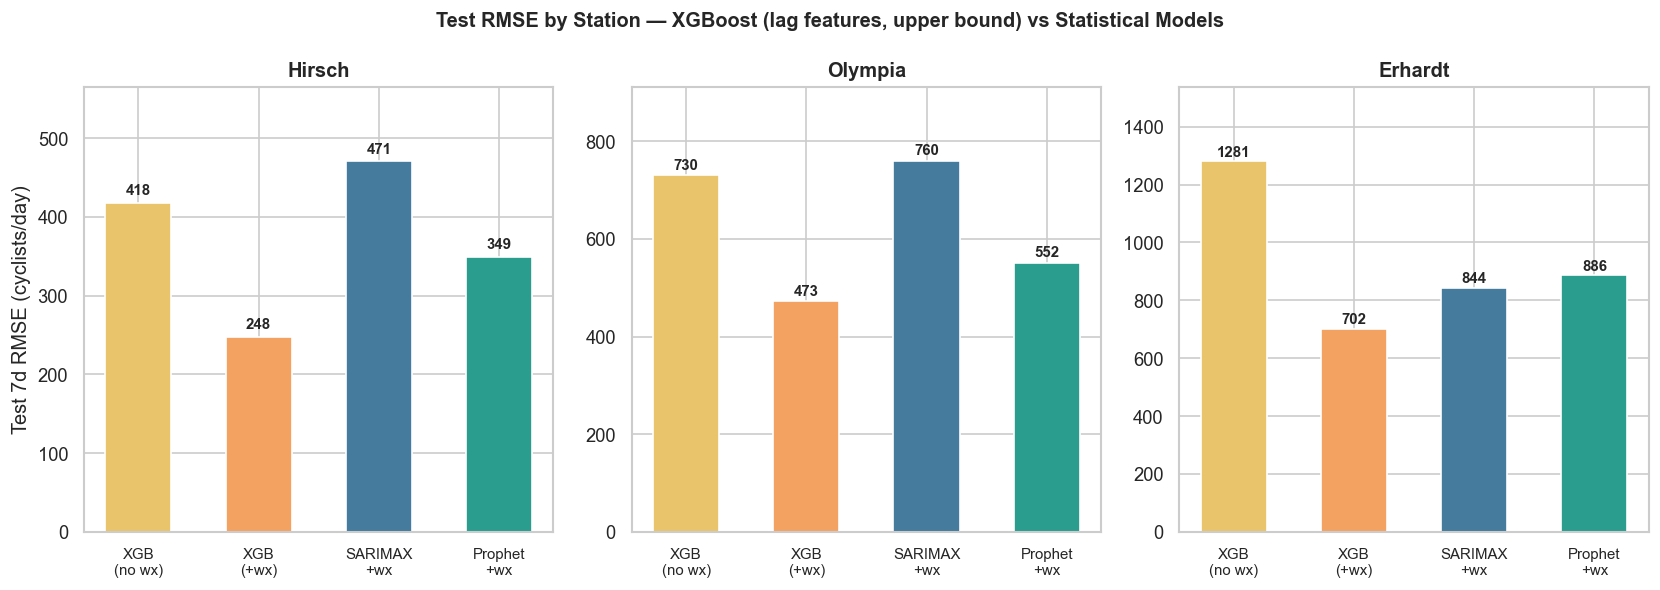

  saved → results/figures/nb11_fig_01_xgboost_rmse_bars.png


In [5]:
bar_labels = ['XGB\n(no wx)', 'XGB\n(+wx)', 'SARIMAX\n+wx', 'Prophet\n+wx']
bar_colors = ['#e9c46a', '#f4a261', '#457b9d', '#2a9d8f']
x = np.arange(len(bar_labels))
width = 0.55

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, station in zip(axes, STATIONS):
    row_nw = results_df[(results_df['Station'] == station) & (results_df['Variant'] == 'no_weather')]
    row_wx = results_df[(results_df['Station'] == station) & (results_df['Variant'] == 'weather')]
    xgb_nw   = row_nw['Test_RMSE'].values[0]
    xgb_wx   = row_wx['Test_RMSE'].values[0]
    sar_rmse = BENCHMARKS[station]['sarimax']
    prp_rmse = BENCHMARKS[station]['prophet']

    vals = [xgb_nw, xgb_wx, sar_rmse, prp_rmse]
    bars = ax.bar(x, vals, width=width, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 6,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_title(station)
    ax.set_ylabel('Test 7d RMSE (cyclists/day)' if station == 'Hirsch' else '')
    ax.set_ylim(0, max(vals) * 1.20)

fig.suptitle(
    'Test RMSE by Station — XGBoost (lag features, upper bound) vs Statistical Models',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
savefig('fig_01_xgboost_rmse_bars')

## Part 6 — nb11_fig_02: Feature Importance Heatmap

Rows = features, columns = stations. Uses `feature_importances_` from the weather variant (refitted on trainval).

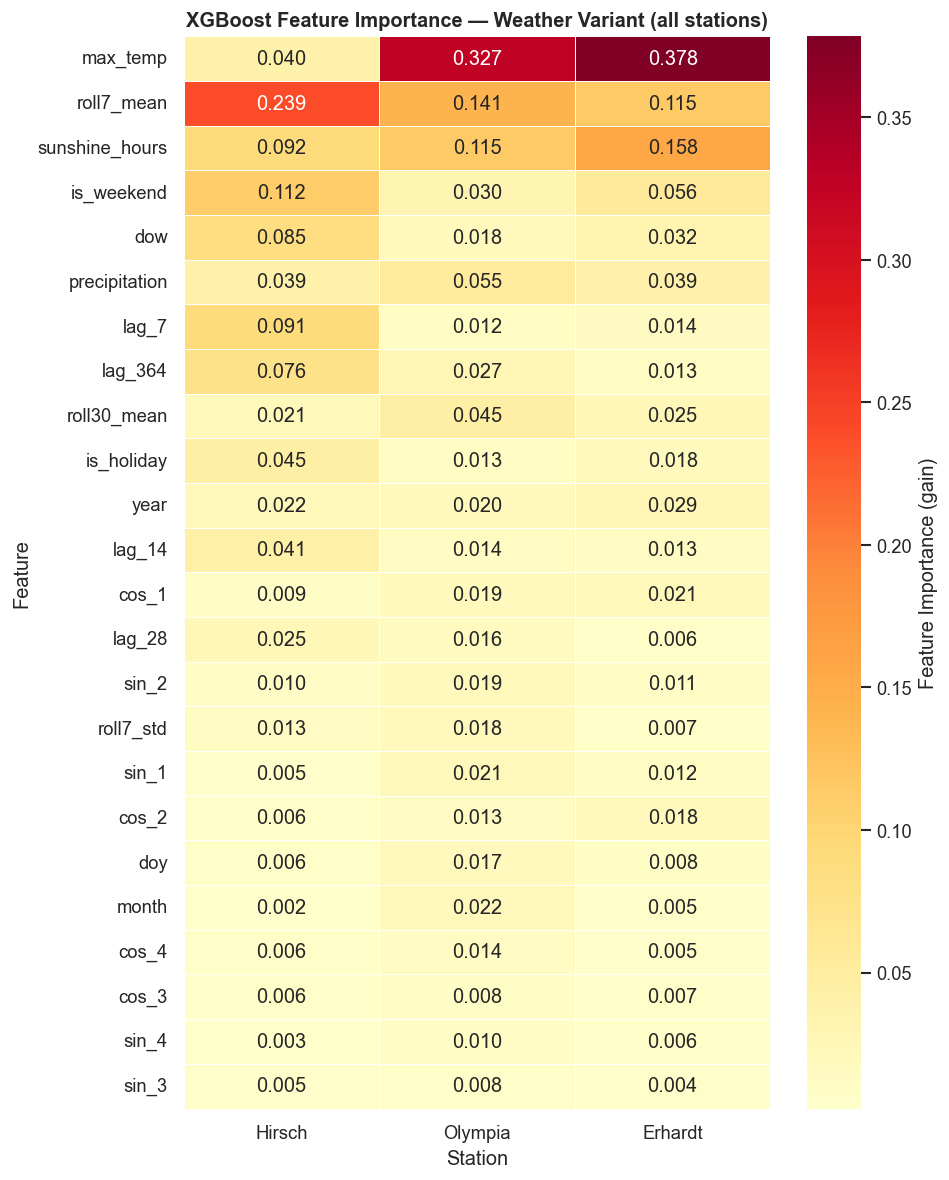

  saved → results/figures/nb11_fig_02_xgboost_feature_importance.png


In [6]:
# Build importance matrix: features x stations
all_feat_names = feature_importances['Hirsch']['names']
imp_matrix = pd.DataFrame(
    {station: dict(zip(feature_importances[station]['names'],
                       feature_importances[station]['importances']))
     for station in STATIONS},
    index=all_feat_names
).fillna(0)

# Sort by mean importance across stations
imp_matrix['_mean'] = imp_matrix.mean(axis=1)
imp_matrix = imp_matrix.sort_values('_mean', ascending=False).drop(columns='_mean')

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    imp_matrix,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Feature Importance (gain)'},
)
ax.set_title('XGBoost Feature Importance — Weather Variant (all stations)')
ax.set_xlabel('Station')
ax.set_ylabel('Feature')
plt.tight_layout()
savefig('fig_02_xgboost_feature_importance')

## Part 7 — Export and Summary

In [7]:
results_df.to_csv(TABLES / 'xgboost_performance.csv', index=False)
print('Saved: xgboost_performance.csv')
print()
print('=' * 60)
print('XGBOOST RESULTS SUMMARY (upper-bound / operational)')
print('=' * 60)
for station in STATIONS:
    row_nw = results_df[(results_df['Station'] == station) & (results_df['Variant'] == 'no_weather')]
    row_wx = results_df[(results_df['Station'] == station) & (results_df['Variant'] == 'weather')]
    nw_rmse = row_nw['Test_RMSE'].values[0]
    wx_rmse = row_wx['Test_RMSE'].values[0]
    wx_gain = round((nw_rmse - wx_rmse) / nw_rmse * 100, 1)
    sar     = BENCHMARKS[station]['sarimax']
    prop    = BENCHMARKS[station]['prophet']
    print(f'{station}:')
    print(f'  XGB no-weather : Test RMSE = {nw_rmse}')
    print(f'  XGB +weather   : Test RMSE = {wx_rmse}  (weather gain: {wx_gain}%)')
    print(f'  SARIMAX+wx (7d): {sar}  |  Prophet+wx (7d): {prop}')
    print(f'  NOTE: XGB uses lag features — not directly comparable to 7-day-ahead models')
print()
print('Top-3 features by mean importance:')
print(imp_matrix.mean(axis=1).nlargest(3).to_string())

Saved: xgboost_performance.csv

XGBOOST RESULTS SUMMARY (upper-bound / operational)
Hirsch:
  XGB no-weather : Test RMSE = 418.2
  XGB +weather   : Test RMSE = 248.1  (weather gain: 40.7%)
  SARIMAX+wx (7d): 471.0  |  Prophet+wx (7d): 349.4
  NOTE: XGB uses lag features — not directly comparable to 7-day-ahead models
Olympia:
  XGB no-weather : Test RMSE = 730.5
  XGB +weather   : Test RMSE = 472.9  (weather gain: 35.3%)
  SARIMAX+wx (7d): 759.8  |  Prophet+wx (7d): 551.7
  NOTE: XGB uses lag features — not directly comparable to 7-day-ahead models
Erhardt:
  XGB no-weather : Test RMSE = 1281.4
  XGB +weather   : Test RMSE = 701.9  (weather gain: 45.2%)
  SARIMAX+wx (7d): 843.5  |  Prophet+wx (7d): 886.0
  NOTE: XGB uses lag features — not directly comparable to 7-day-ahead models

Top-3 features by mean importance:
max_temp          0.248566
roll7_mean        0.165047
sunshine_hours    0.121784
